In [1]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress

df = pd.read_csv("FPI-1-11-26.csv")

dfs = {}
for year in range(2015, 2025):
    dfs[year] = pd.read_csv(f"FPI_Years/FPI_{year}.csv")
    
team_to_abbr = {"Arizona Cardinals":"ARI",
    "Atlanta Falcons":"ATL",
    "Baltimore Ravens":"BAL",
    "Buffalo Bills":"BUF",
    "Carolina Panthers":"CAR",
    "Chicago Bears":"CHI",
    "Cincinnati Bengals":"CIN",
    "Cleveland Browns":"CLE",
    "Dallas Cowboys":"DAL",
    "Denver Broncos":"DEN",
    "Detroit Lions":"DET",
    "Green Bay Packers":"GB",
    "Houston Texans":"HOU",
    "Indianapolis Colts":"IND",
    "Jacksonville Jaguars":"JAX",
    "Kansas City Chiefs":"KC",
    "Las Vegas Raiders":"LV",
    "Los Angeles Chargers":"LAC",
    "Los Angeles Rams":"LA",
    "Miami Dolphins":"MIA",
    "Minnesota Vikings":"MIN",
    "New England Patriots":"NE",
    "New Orleans Saints":"NO",
    "New York Giants":"NYG",
    "New York Jets":"NYJ",
    "Philadelphia Eagles":"PHI",
    "Pittsburgh Steelers":"PIT",
    "San Francisco 49ers":"SF",
    "Seattle Seahawks":"SEA",
    "Tampa Bay Buccaneers":"TB",
    "Tennessee Titans":"TEN",
    "Washington Commanders":"WAS"
    }

corrected_teams = {"Oakland Raiders": "Las Vegas Raiders",
                   "St. Louis Rams": "Los Angeles Rams",
                   "San Diego Chargers": "Los Angeles Chargers"}

# Introduction #

Add intro and explain stuff.

### Research Questions: ###
Do current tiebreakers select the stronger team?  
How much more accurate can we get with alternative methods?  
What is the optimal cap for a capped margin tiebreaker?  
How often does the #1 FPI team end up as the "best team"?  
How does season length affect identifying the "best team"?  
Do simulation findings align with real NFL data?  
How well does the previous year's FPI predict playoffs?  


# Framework and Background Information #

### FPI ###
Explain what FPI is and how this project will be using it.
### Game Simulation ###
Explain how each game is simulated

The way each game is simulated depends heavily on the FPI values assigned to each team. In the model, the difference in FPI between two teams directly shifts the expected margin:

$$
\text{margin} = (score_1 - score_2) + \text{home\_field} + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0,1)
$$

For the simulations, FPI values are generated with a mean of 0.016 and a standard deviation of 3. The mean comes from the average FPI across real seasons.  

The standard deviation of 3 was chosen after testing different values. Using the real FPI spread made the results too extreme, with too many teams going 0–17 or 17–0. Lower values were too tight and didn’t produce enough variation. A value of 3 gave the best balance, matching the real distribution of team wins pretty closely.

### Schedule Generation & Simulation ###
Explain how the schedule is generated and simulated
### Playoff Construction & Tiebreakers ###
Explain how playoff field is generated and the tiebreakers involved to allow this to happen
### Real NFL Data ###
Explain how real NFL data can be imported via nflreadpy

# Tiebreakers #

### How often is each tiebreaker used? ###
Depending on the situation, there is up to 12 tiebreakers to break a tie in the NFL standings. Starting with head to head record and ending with a coin toss. In this section, we will run simulations to see how deep we typically get into the tiebreaker hiearchy. We will then compare that to real NFL results. For the purposes of this project, we will only be going 6 layers deep into the tiebreaker chain.

Coin flip! Betwee ['Green Bay Packers', 'Arizona Cardinals']


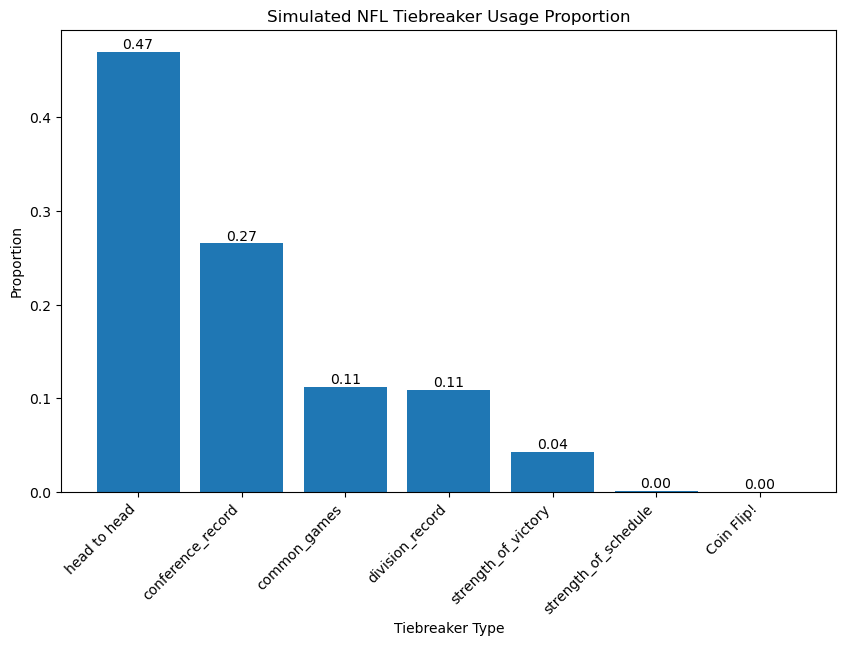

In [19]:
# 1000 sims on the random FPI and random seed
n = 1000

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()
for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

labels = list(tb_counts.keys())
counts = list(tb_counts.values())

sorted_items = sorted(tb_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*sorted_items)

total_count = sum(counts)
proportions = [c / total_count for c in counts]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, proportions)

plt.title("Simulated NFL Tiebreaker Usage Proportion")
plt.xlabel("Tiebreaker Type")
plt.ylabel("Proportion")
plt.bar_label(bars, fmt="%.2f")
plt.xticks(rotation=45, ha="right")
plt.show()

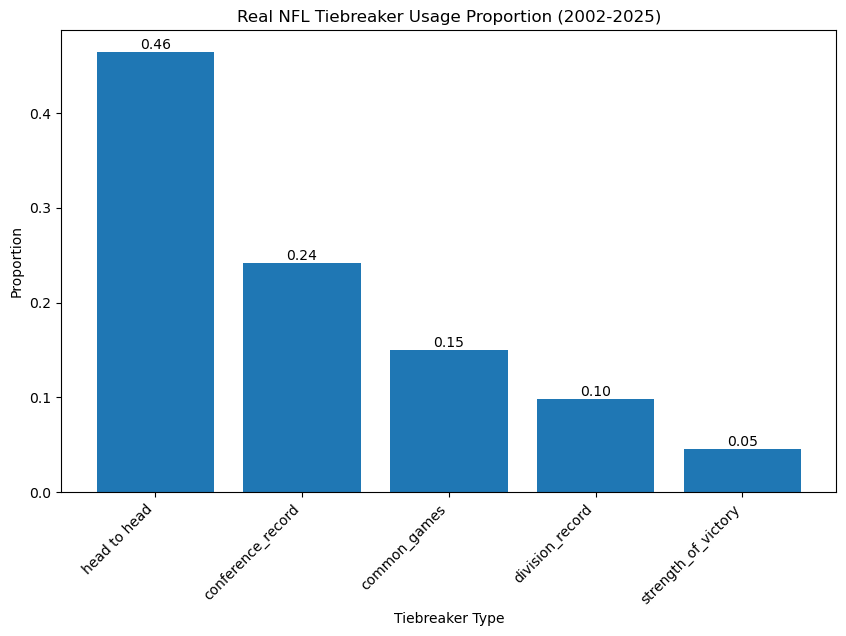

In [35]:
tb_counts_real = Counter()
fpi_counts_real = Counter()
field_count_real = Counter()

# Loop through the years and count the # of tiebreakers
for year in range(2002, 2026):
    results_df_real, standings_df_real = build_real_season_dfs(year)
    if year in dfs:
        standings_df_real["FPI"] = dfs[year]["FPI"].values
    
    field_real, tbs_real, fpi_winners_real = playoff_field(standings_df_real, results_df_real)
    filtered_tbs_real = [tb for tb in tbs_real if tb != "win percentage diff"]
    tb_counts_real.update(Counter(filtered_tbs_real))
    fpi_counts_real.update(Counter(fpi_winners_real))
    field_count_real.update(Counter(field_real["Team"]))

sorted_items_real = sorted(total_real.items(), key=lambda x: x[1], reverse=True)
labels_real, counts_real = zip(*sorted_items_real)

total_count_real = sum(counts_real)
proportions_real = [c / total_count_real for c in counts_real]

plt.figure(figsize=(10, 6))
bars_real = plt.bar(labels_real, proportions_real)

plt.title("Real NFL Tiebreaker Usage Proportion (2002-2025)")
plt.xlabel("Tiebreaker Type")
plt.ylabel("Proportion")
plt.bar_label(bars_real, fmt="%.2f")
plt.xticks(rotation=45, ha="right")
plt.show()

### Does the higher FPI team usually win the tiebreaker? ###
We may know how tiebreakers are distributed, but how good are they at picking the "correct" team. If we assume that FPI is the end-all, be-all for determining 1 team is better than the other, how do the NFL's current tiebreaker set-up pick the "right" team? We will first look at our simulation and then the actual NFL results.

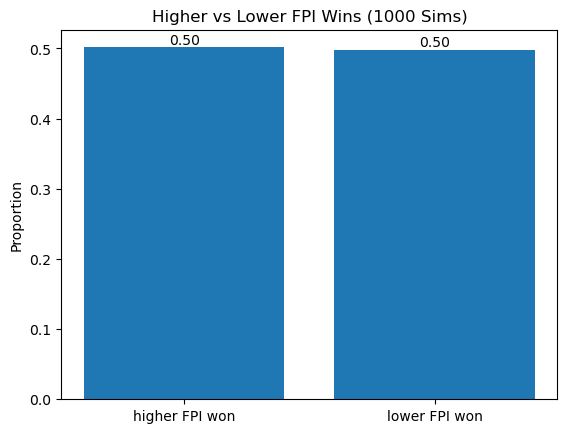

In [36]:
fpi_hist_df = pd.Series(fpi_counts)

# Convert to proportions (density)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values)

plt.ylabel("Proportion")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")

# Add labels on bars
plt.bar_label(bars, fmt="%.2f")

plt.show()

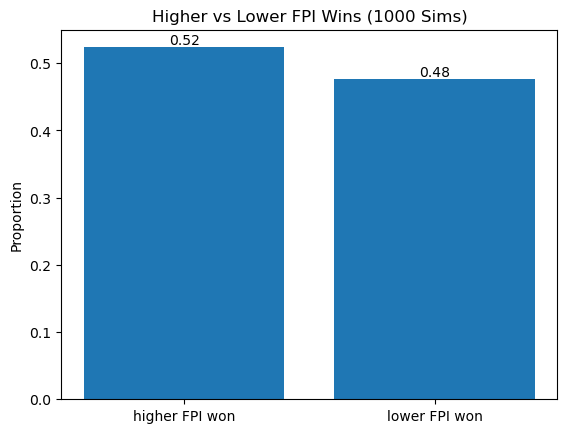

In [37]:
fpi_hist_df = pd.Series(fpi_counts_real)

# Convert to proportions (density)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values)

plt.ylabel("Proportion")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")

# Add labels on bars
plt.bar_label(bars, fmt="%.2f")

plt.show()

### What if we use total margin (ie, Point Differential) as a tiebreaker? ###

In [41]:
n = 1000
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df, mode = "total_margin") #tie_breaker is just point differential

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

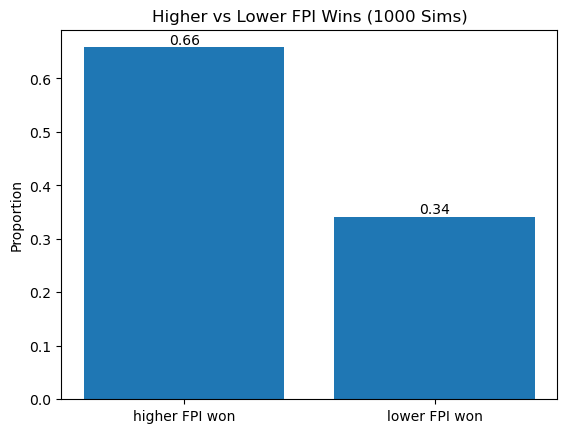

In [42]:
fpi_hist_df = pd.Series(fpi_counts)

# Convert to proportions (density)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values)

plt.ylabel("Proportion")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")

# Add labels on bars
plt.bar_label(bars, fmt="%.2f")

plt.show()

### What if we cap the margin?

In [58]:
n = 100
tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()

for sim_seed in range(1, n + 1):
    df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=sim_seed)
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed, tm_cap = )

    field, tiebreakers, fpi_winners = playoff_field(standings_df, 
                                        results_df, mode = "capped_margin") #tie_breaker is just point differential

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))

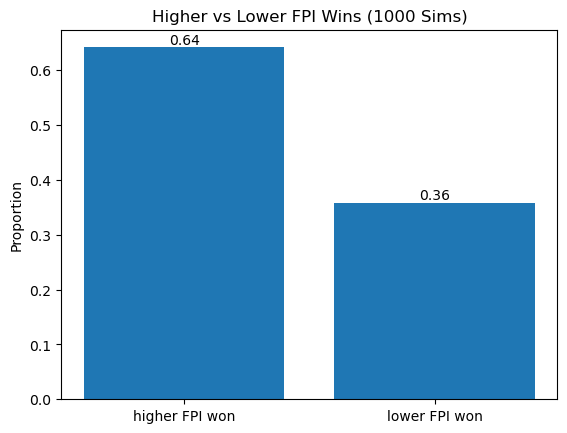

In [59]:
fpi_hist_df = pd.Series(fpi_counts)

# Convert to proportions (density)
total = fpi_hist_df.sum()
proportions = fpi_hist_df / total

plt.figure()
bars = plt.bar(proportions.index, proportions.values)

plt.ylabel("Proportion")
plt.title("Higher vs Lower FPI Wins (1000 Sims)")

# Add labels on bars
plt.bar_label(bars, fmt="%.2f")

plt.show()

### What would be the optimal cap to maximize the higher FPI team winning?

### How does the optimal capped method work on real NFL data?

# Identifying Best Team #

### How often does the #1 FPI team (per conference) end up being a 1 seed? ###

### How does season length affect the proportion of the true #1 team being the 1 seed? ###



# Prediction and Forecasting #

### How well does the previous season’s FPI predict the next season’s playoff field? ###


